In [ ]:
# Install required libraries
# google-genai → Required to access Gemini API for generating embeddings
# xgboost → for classification model
# wordcloud → for visualization

!pip install google-genai xgboost wordcloud --quiet

In [ ]:
# Data Handling
import pandas as pd      # For loading and managing the dataset
import numpy as np       # For numerical operations on embeddings

# Visualization (EDA)
import matplotlib.pyplot as plt   # Basic plotting
import seaborn as sns             # Better statistical visualizations

# Text Preprocessing
import re   # For cleaning tweets (removing URLs, mentions, etc.)

# Gemini API
from google import genai   # To generate text embeddings using Gemini

# Machine Learning
from sklearn.model_selection import train_test_split  # Train-test split
from sklearn.linear_model import LogisticRegression   # Baseline classifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score  # Model evaluation

# Advanced Model
from xgboost import XGBClassifier   # Gradient boosting classifier

# Visualization - Word Cloud
from wordcloud import WordCloud   # To visualize most frequent words

In [ ]:
# Set your Gemini API key
API_KEY = "Gemini_API_Key"

# Initialize Gemini client
client = genai.Client(api_key=API_KEY)

In [ ]:
# Load the dataset
df = pd.read_csv("/content/Tweets.csv")

words = [
    str(x)
    for x in df["text"]
    if pd.notna(x) and str(x).strip() != ""
]
words = words[:800]
# Display first 5 rows
df.head(800) #we will use the first 900 tweets for handling gemini rate limit errors

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative
...,...,...,...,...
795,27f1fa3214,haha best thing about office birthdays hey,best,positive
796,233b90417d,"****, I never knew I could miss my phone so mu...","****,",negative
797,0d32a589d2,_Lay aww well I just randomly woke up and now ...,aww,negative
798,0aa7e2d375,That`s it? It`s done already? This is one proo...,nothing fair,negative


In [ ]:
# Check dataset shape (rows, columns)
df.shape

(27481, 4)

In [ ]:
# Check column names
df.columns

Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='object')

In [ ]:
# Check for missing values
df.isnull().sum()

,0
textID,0
text,1
selected_text,1
sentiment,0


In [ ]:
# Keep only required columns
df = df[['text', 'sentiment']]

# Drop rows where text is missing
df = df.dropna(subset=['text'])

# Reset index after dropping rows
df = df.reset_index(drop=True)

# Check new shape
df.shape


(27480, 2)

In [ ]:
# Count number of tweets in each sentiment
sentiment_counts = df['sentiment'].value_counts()

sentiment_counts

,count
sentiment,
neutral,11117
positive,8582
negative,7781


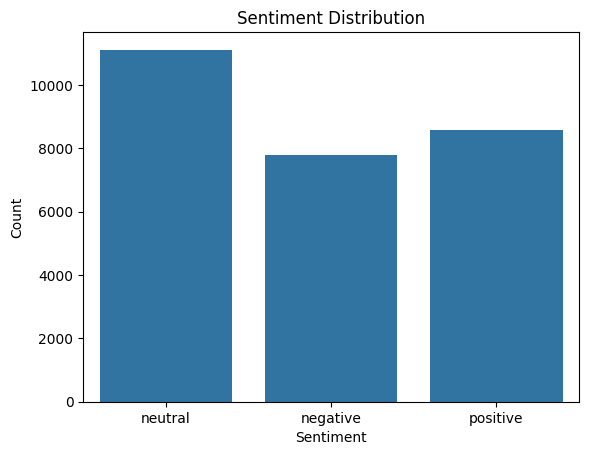

In [ ]:
# Plot sentiment distribution
sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

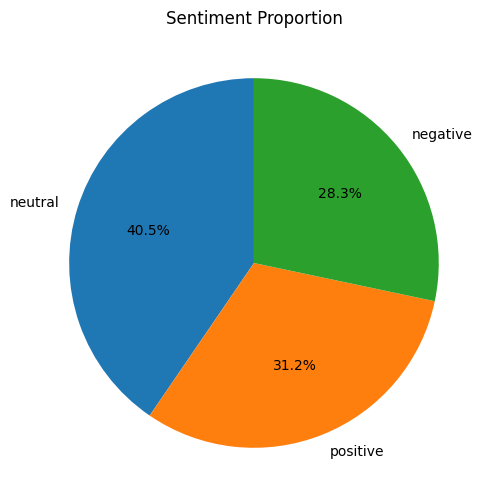

In [ ]:
# Pie chart for sentiment proportion
plt.figure(figsize=(6,6))

plt.pie(sentiment_counts,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Sentiment Proportion")
plt.show()

The dataset contains three sentiment classes: Neutral (40.5%), Positive (31.2%), and Negative (28.3%). The dataset is moderately imbalanced with Neutral tweets being the most frequent.

In [ ]:
# Create a column for tweet length (number of characters)
df['text'] = df['text'].fillna('')
df['text_length'] = df['text'].apply(len)

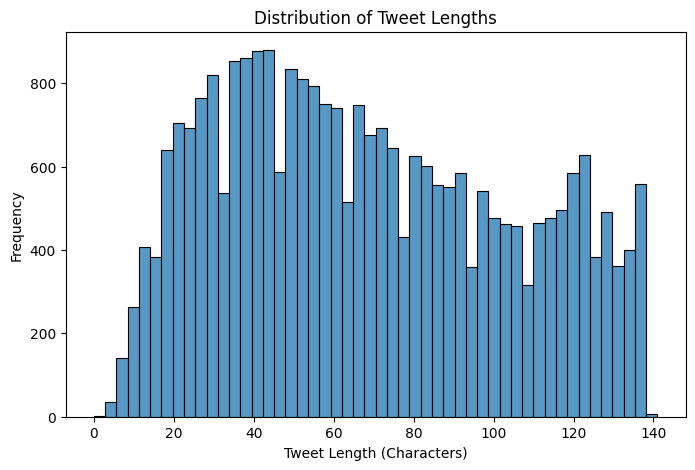

In [ ]:
# Plot histogram of tweet lengths
plt.figure(figsize=(8,5))

sns.histplot(df['text_length'], bins=50)

plt.title("Distribution of Tweet Lengths")
plt.xlabel("Tweet Length (Characters)")
plt.ylabel("Frequency")
plt.show()

The histogram shows that tweet lengths range up to approximately 140 characters. Most tweets fall between 20 and 100 characters, indicating moderate-length content. The distribution appears fairly spread out without extreme outliers, which is consistent with typical tweet length constraints.

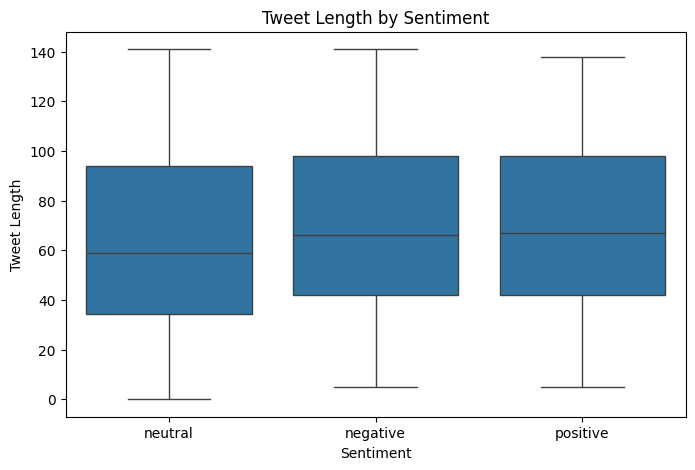

In [ ]:
# Boxplot of tweet length by sentiment
plt.figure(figsize=(8,5))

sns.boxplot(x='sentiment', y='text_length', data=df)

plt.title("Tweet Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Length")
plt.show()

The boxplot shows that tweet lengths are relatively similar across neutral, negative, and positive sentiments. The median length for all three categories is close, indicating that sentiment does not strongly influence tweet length. The spread of values is also comparable across categories.

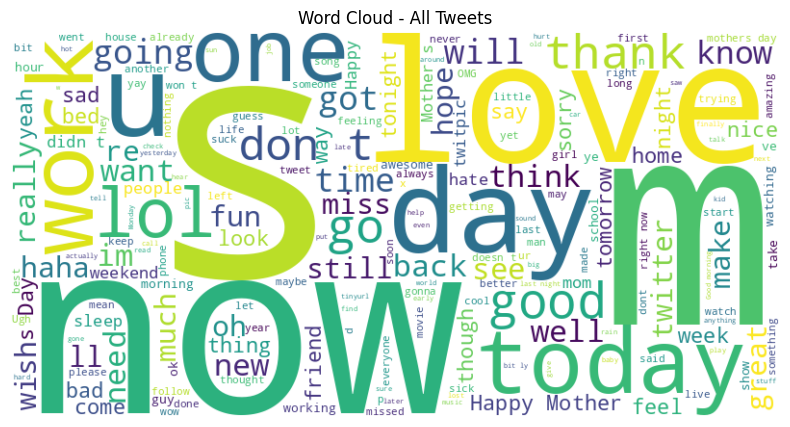

In [ ]:
# Word Cloud For All Tweets
# Combine all tweet text into one large string
all_text = " ".join(df['text'])

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_text)

# Plot word cloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - All Tweets")
plt.show()

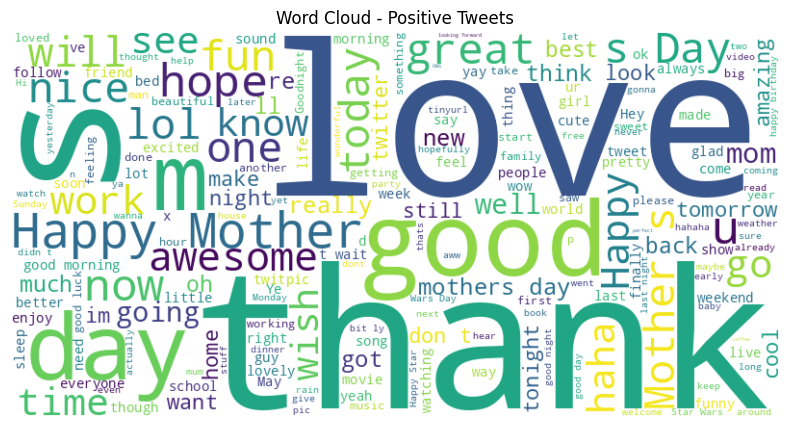

In [ ]:
# Word Cloud For Positive Tweets
# Combine all positive tweets into one string
positive_text = " ".join(df[df['sentiment'] == 'positive']['text'])

# Generate word cloud
positive_wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

# Plot
plt.figure(figsize=(10,5))
plt.imshow(positive_wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - Positive Tweets")
plt.show()

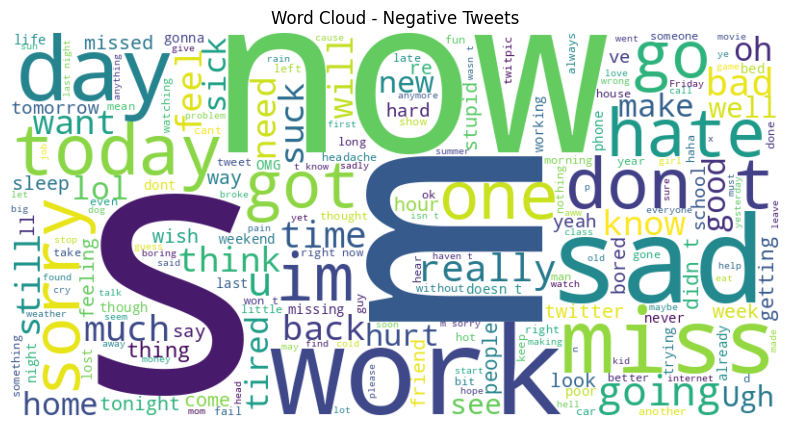

In [ ]:
# Word Cloud For All Negative Tweets
# Combine all negative tweets into one string
negative_text = " ".join(df[df['sentiment'] == 'negative']['text'])

# Generate word cloud
negative_wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

# Plot
plt.figure(figsize=(10,5))
plt.imshow(negative_wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - Negative Tweets")
plt.show()

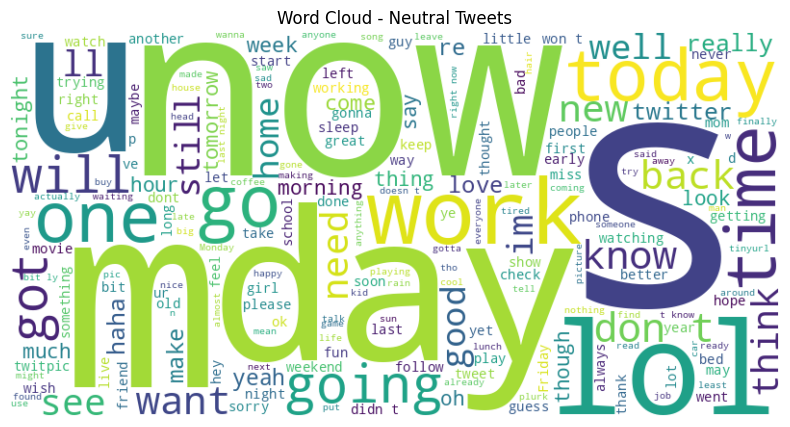

In [ ]:
# Word Cloud For All Neutral Tweets
# Combine all neutral tweets into one string
neutral_text = " ".join(df[df['sentiment'] == 'neutral']['text'])

# Generate word cloud
neutral_wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(neutral_text)

# Plot
plt.figure(figsize=(10,5))
plt.imshow(neutral_wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - Neutral Tweets")
plt.show()

The sentiment-wise word clouds reveal differences in vocabulary across classes. Positive tweets frequently contain optimistic and appreciative words, negative tweets highlight dissatisfaction or criticism, while neutral tweets contain more general or informational terms.

In [ ]:
def get_gemini_embeddings(texts, model="models/gemini-embedding-001"):
    """
    Generate embeddings using NEW Google GenAI SDK
    Args:
        texts: string or list[str]
    Returns:
        numpy array of embedding vectors
    """
    if isinstance(texts, str):
        texts = [texts]

    embeddings = []
    for text in texts:
        result = client.models.embed_content(
            model=model,
            contents=text
        )
        embeddings.append(result.embeddings[0].values)

    return np.array(embeddings)

In [ ]:
import time
import re
import numpy as np

def get_gemini_embeddings_ld(texts, model="models/gemini-embedding-001", batch_size=50, per_request_sleep=0.85): #hold 0.25 seconds before the next api call to handle rate limit errors
    """
   Large-data embedding generator (rate-limit safe)
   Batched embedding generator to avoid rate limit errors
    Args:
        texts: list of strings
        model: Gemini embedding model
    Returns:
        numpy array of embeddings
    """

    embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        for j, text in enumerate(batch):
            while True:
                try:
                    result = client.models.embed_content(
                        model=model,
                        contents=text
                    )
                    embeddings.append(result.embeddings[0].values)

                    # small pacing delay to reduce 429 hits
                    time.sleep(per_request_sleep)
                    break

                except Exception as e:
                    err = str(e)

                    # Handle Gemini free-tier quota limit
                    if "429" in err or "RESOURCE_EXHAUSTED" in err:
                        match = re.search(r"retry in ([0-9.]+)s", err)
                        wait_time = float(match.group(1)) if match else 25.0

                        done = len(embeddings)
                        total = len(texts)

                        print(f" Rate limit hit at {done}/{total}. Waiting {wait_time:.2f}s...")
                        time.sleep(wait_time + 1)

                    else:
                        raise e

        print(f" Completed batch {i//batch_size + 1} | Embedded {len(embeddings)}/{len(texts)}")

    return np.array(embeddings)

In [ ]:
# Generate embeddings for the large list of words
embeddings = get_gemini_embeddings_ld(words)

 Completed batch 1 | Embedded 50/800
 Completed batch 2 | Embedded 100/800
 Completed batch 3 | Embedded 150/800
 Completed batch 4 | Embedded 200/800
 Completed batch 5 | Embedded 250/800
 Completed batch 6 | Embedded 300/800
 Completed batch 7 | Embedded 350/800
 Completed batch 8 | Embedded 400/800
 Completed batch 9 | Embedded 450/800
 Completed batch 10 | Embedded 500/800
 Completed batch 11 | Embedded 550/800
 Completed batch 12 | Embedded 600/800
 Completed batch 13 | Embedded 650/800
 Completed batch 14 | Embedded 700/800
 Completed batch 15 | Embedded 750/800
 Completed batch 16 | Embedded 800/800


In [ ]:
df.sentiment.unique()

array(['neutral', 'negative', 'positive'], dtype=object)

In [ ]:
y = df["sentiment"].map({"negative": 0, "positive": 1, "neutral" : 2}).values
X = embeddings

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y[:800], test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 640
Test size: 160


In [ ]:
label_map = {0: "Negative", 1: "Positive", 2: "Neutral"}

def predict_sentiment(model, texts):
    # If a single string is passed, convert to list
    single_input = False
    if isinstance(texts, str):
        texts = [texts]
        single_input = True

    # Get embeddings for all inputs
    embeddings = get_gemini_embeddings(texts)

    # Predict
    preds = model.predict(embeddings)
    probs = model.predict_proba(embeddings)

    # Convert numeric labels to text labels
    results = [
    f"{label_map[p]}, Probability_score: {max(prob):.2f}"
    for p, prob in zip(preds, probs)
    ]


    # Return single value if original input was single string
    if single_input:
        return results[0]

    return results

# **Training using XGBoost Classifier**

In [ ]:
# Train XGBoost classifier
clf_xgb = XGBClassifier(objective="binary:logistic", eval_metric="logloss")
clf_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Evaluate model
y_pred = clf_xgb.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive","Neutral"]))

              precision    recall  f1-score   support

    Negative       0.35      0.40      0.37        43
    Positive       0.37      0.24      0.29        54
     Neutral       0.43      0.52      0.47        63

    accuracy                           0.39       160
   macro avg       0.38      0.39      0.38       160
weighted avg       0.39      0.39      0.38       160



In [ ]:
# Example Prediction
sample = "I love this phone"
print("Review:", sample)
print("Prediction:", predict_sentiment(clf_xgb, sample))

Review: I love this phone
Prediction: Positive, Probability_score: 0.66


In [ ]:
# Custom tweets (all sentiments included)
custom_tweets = [
    "The service was quick and the staff were extremely helpful",   # positive
    "I regret buying this, total waste of money",                   # ve
    "The event was fine, nothing particularly special",              # neutralnegati
    "I'm impressed with how smoothly everything worked",             # positive
    "The update caused more problems than it solved"                 # negative
]
print("Review:", custom_tweets)
print("Prediction:", predict_sentiment(clf_xgb, custom_tweets))

Review: ['The service was quick and the staff were extremely helpful', 'I regret buying this, total waste of money', 'The event was fine, nothing particularly special', "I'm impressed with how smoothly everything worked", 'The update caused more problems than it solved']
Prediction: ['Negative, Probability_score: 0.65', 'Negative, Probability_score: 0.95', 'Neutral, Probability_score: 0.75', 'Positive, Probability_score: 0.91', 'Negative, Probability_score: 0.59']


In [ ]:
# Model Evaluation Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.39375


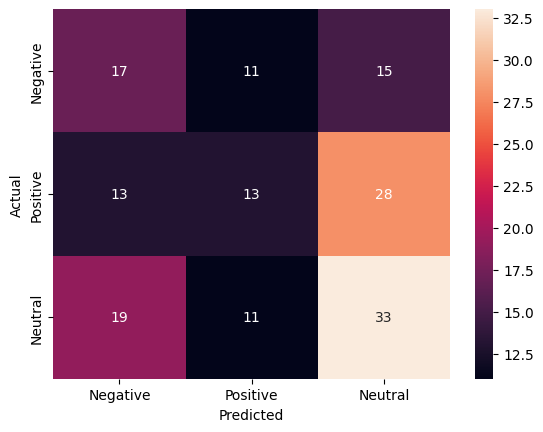

In [ ]:
# Model Evaluation Metrics
# CConfusion Matrix & Interpretation
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Negative","Positive","Neutral"],
            yticklabels=["Negative","Positive","Neutral"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Confusion Matrix Interpretation

The model was trained using Gemini-generated text embeddings. Due to API rate-limit constraints, only 800 tweets were embedded and used for training and evaluation.

On the test set (160 samples), the model achieved an overall accuracy of approx 40%, which is slightly above the random baseline (~33%) for a three-class classification problem.

The confusion matrix indicates substantial misclassification between the Neutral and both Positive and Negative classes. In particular, many Positive tweets were predicted as Neutral, and a notable portion of Negative tweets were also classified as Neutral. This suggests difficulty in distinguishing subtle sentiment differences.

The moderate performance is likely influenced by the limited training size. Increasing the number of embedded samples and applying class balancing techniques may improve classification performance.

# **Training Using Logistic Regression (baseline linear classifier)**

In [ ]:
clf_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # helps if classes are uneven
    multi_class="multinomial",
    solver="lbfgs"
)

In [ ]:
clf_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=1000,
                   multi_class='multinomial')

In [ ]:
y_pred_lr = clf_lr.predict(X_test)

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        labels=[0,1,2],
        target_names=["Negative", "Positive", "Neutral"]
    )
)

              precision    recall  f1-score   support

    Negative       0.35      0.44      0.39        43
    Positive       0.45      0.46      0.46        54
     Neutral       0.48      0.38      0.42        63

    accuracy                           0.42       160
   macro avg       0.43      0.43      0.42       160
weighted avg       0.44      0.42      0.43       160



In [ ]:
# Example Prediction
sample = "I love this phone"
print("Review:", sample)
print("Prediction:", predict_sentiment(clf_lr, sample))

Review: I love this phone
Prediction: Positive, Probability_score: 0.54


In [ ]:
# Custom tweets (all sentiments included)
custom_tweets = [
    "The service was quick and the staff were extremely helpful",   # positive
    "I regret buying this, total waste of money",                   # negative
    "The event was fine, nothing particularly special",              # neutral
    "I'm impressed with how smoothly everything worked",             # positive
    "The update caused more problems than it solved"                 # negative
]
print("Review:", custom_tweets)
print("Prediction:", predict_sentiment(clf_lr, custom_tweets))

Review: ['The service was quick and the staff were extremely helpful', 'I regret buying this, total waste of money', 'The event was fine, nothing particularly special', "I'm impressed with how smoothly everything worked", 'The update caused more problems than it solved']
Prediction: ['Positive, Probability_score: 0.44', 'Negative, Probability_score: 0.65', 'Neutral, Probability_score: 0.41', 'Positive, Probability_score: 0.54', 'Negative, Probability_score: 0.48']


In [ ]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.425


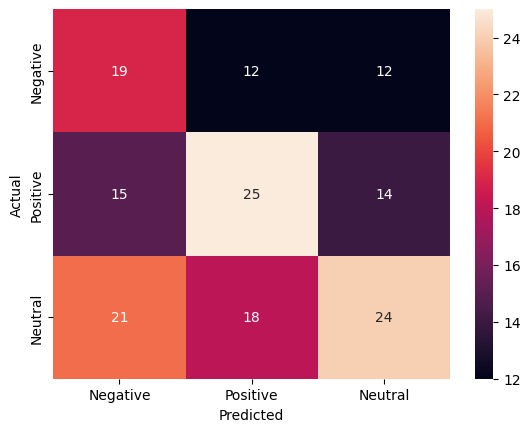

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt="d",
            xticklabels=["Negative","Positive","Neutral"],
            yticklabels=["Negative","Positive","Neutral"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Confusion Matrix Interpretation (Logistic Regression)

The Logistic Regression model was evaluated on 160 test samples using embeddings generated from 800 tweets (limited due to Gemini API rate constraints). The model achieved an overall accuracy of 42.5%.

From the confusion matrix:

Negative: 19 correctly classified; misclassifications are distributed between Positive and Neutral.

Positive: 25 correctly classified; still shows confusion with both Negative and Neutral.

Neutral: 24 correctly classified; notable misclassification into Negative and Positive remains.

Overall, the model demonstrates a slightly improved and more balanced performance compared to earlier results. However, substantial overlap persists among the three sentiment classes, particularly between Neutral and the other categories. The moderate accuracy is likely influenced by the limited training size (800 samples), and performance may improve with a larger embedded dataset.

### **Sentiment Analysis Model Report**

1. **Model Interpretation**

Logistic Regression (LR):

A linear model that predicts sentiment using weighted word features.

More interpretable and stable on small datasets.

Produced the correct prediction for the first review, but with low confidence (0.44), showing uncertainty.

XGBoost (XGB):

A tree-based boosting model that captures non-linear relationships.

Generated higher confidence scores overall.

Misclassified the first clearly positive review as Negative (0.65), suggesting possible overfitting or feature limitations.

2. **Model Comparison**

| Aspect                  | Logistic Regression   | XGBoost                    |
| ----------------------- | --------------------- | -------------------------- |
| Model Type              | Linear                | Non-linear (Tree-based)    |
| Complexity              | Simple                | More complex               |
| Interpretability        | High                  | Moderate                   |
| Handles Non-linearity   | No                    | Yes                        |
| Confidence Scores       | Lower / closer to 0.5 | More extreme probabilities |
| First Sample Prediction | Correct               | Incorrect                  |

Observation:

Logistic Regression produced a correct prediction for the first review.

XGBoost produced higher confidence predictions overall.

Neither model demonstrates strong overall accuracy (based on earlier 42.5% result).

Performance differences may be due to dataset size, feature representation, or hyperparameter tunin

# **Conclusion**
Both models demonstrate strengths and limitations.
Logistic Regression provides better interpretability and simpler implementation, while XGBoost offers higher modeling complexity and potentially better performance with proper tuning.

Logistic Regression is more stable and interpretable for small text datasets.

XGBoost may perform better with larger datasets and well-engineered features.

Probability scores close to 0.5 indicate model uncertainty.